# Acer Platanoides – Image Viewer with Bounding Boxes

Displays all images whose filename contains `acer platanoides`, with every bounding box in the corresponding YOLO `.txt` label file drawn on top.
Images without a `.txt` file are shown without boxes (no annotations).

In [1]:
import os
import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

DATA_DIR = Path("/storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/selection4class_training_27052024")
SPECIES = "acer platanoides"
CLASS_ID = 36  # 0-indexed YOLO class ID for acer platanoides

In [2]:
# Collect all acer platanoides images
images = sorted([p for p in DATA_DIR.glob("*.png") if SPECIES in p.name.lower()])
print(f"Found {len(images)} images for '{SPECIES}'")
for img in images:
    has_label = img.with_suffix(".txt").exists()
    print(f"  {img.name}  {'[has labels]' if has_label else '[NO LABELS]'}")

Found 6 images for 'acer platanoides'
  20190429-37-acer platanoides-20180904-#0031.png  [NO LABELS]
  20190429-37-acer platanoides-20180904-#0033.png  [has labels]
  20190429-37-acer platanoides-20180904-#0059.png  [has labels]
  20190429-37-acer platanoides-20180904-#0084.png  [NO LABELS]
  20190429-37-acer platanoides-20180904-#0095.png  [has labels]
  20190429-37-acer platanoides-20180904-#0158.png  [has labels]


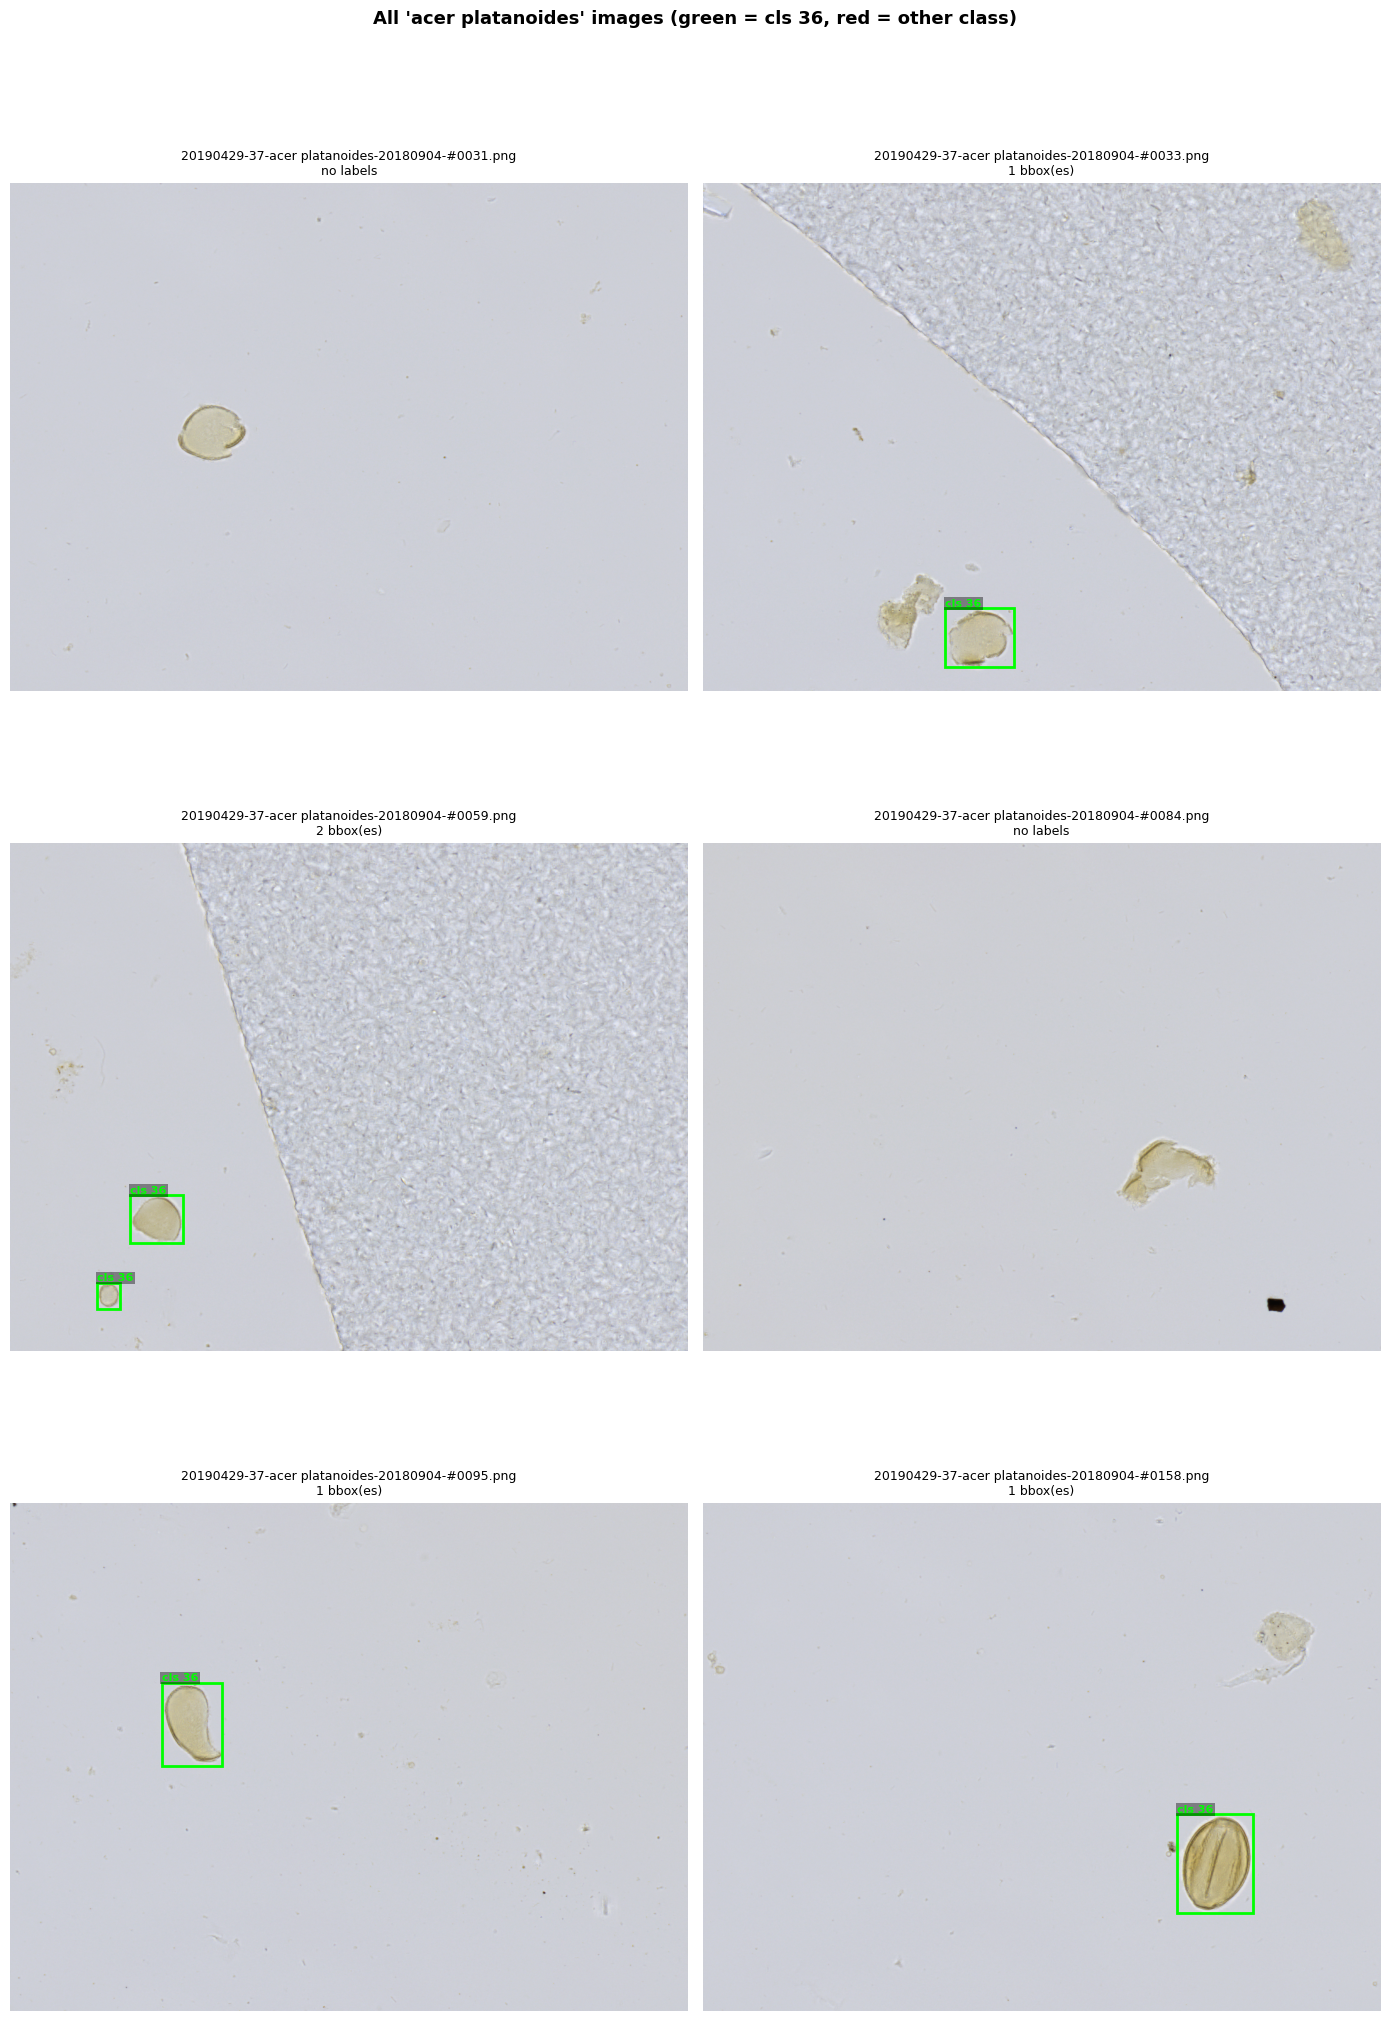

In [3]:
def load_yolo_boxes(label_path: Path, img_w: int, img_h: int):
    """Parse YOLO label file and return list of (class_id, x1, y1, x2, y2) in pixel coords."""
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = int((cx - bw / 2) * img_w)
            y1 = int((cy - bh / 2) * img_h)
            x2 = int((cx + bw / 2) * img_w)
            y2 = int((cy + bh / 2) * img_h)
            boxes.append((cls, x1, y1, x2, y2))
    return boxes


# Color: green for the acer platanoides class, red for any other class that may appear
def box_color(cls):
    return "lime" if cls == CLASS_ID else "red"


ncols = 2
nrows = (len(images) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 7 * nrows))
axes = np.array(axes).reshape(-1)  # flatten for easy indexing

for ax, img_path in zip(axes, images):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        ax.set_title(f"{img_path.name}\n[FAILED TO LOAD]")
        ax.axis("off")
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    label_path = img_path.with_suffix(".txt")
    boxes = load_yolo_boxes(label_path, w, h)

    ax.imshow(img_rgb)
    for cls, x1, y1, x2, y2 in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=box_color(cls), facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"cls {cls}", color=box_color(cls),
                fontsize=8, fontweight="bold",
                bbox=dict(facecolor="black", alpha=0.4, pad=1, linewidth=0))

    status = f"{len(boxes)} bbox(es)" if boxes else "no labels"
    ax.set_title(f"{img_path.name}\n{status}", fontsize=9)
    ax.axis("off")

# Hide unused subplots
for ax in axes[len(images):]:
    ax.set_visible(False)

fig.suptitle(f"All '{SPECIES}' images (green = cls {CLASS_ID}, red = other class)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()